# Compare Models: Reconstruction Errors and MST Metrics
Load summary JSON outputs created by notebook 11 and compare models.

In [33]:
from pathlib import Path
import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm

pd.set_option("display.max_columns", 50)
pd.set_option("display.width", 120)

In [34]:
project_root = Path.cwd().resolve().parent
results_root = project_root / "results"

DATASET_NAME = "data_00_20_w252_s5"
FORWARD_DAYS = 21
DATASET = 'train'  # 'train', 'val', 'test' or 'all'
dataset_dir = results_root / DATASET_NAME / f'{FORWARD_DAYS}_days_gap'
analysis_dir = dataset_dir / f"reconstruction_analysis_{DATASET}"
comparison_dir = dataset_dir / f"comparison_{DATASET}"
comparison_dir.mkdir(parents=True, exist_ok=True)

if not dataset_dir.exists():
    available = [p.name for p in results_root.iterdir() if p.is_dir()]
    raise FileNotFoundError(f"Dataset not found: {dataset_dir}. Available: {available}")

if not analysis_dir.exists():
    raise FileNotFoundError(f"Missing reconstruction_analysis folder: {analysis_dir}")

model_dirs = sorted([p for p in analysis_dir.iterdir() if p.is_dir()])
model_names = [p.name for p in model_dirs]

print(f"Models found ({len(model_names)}): {model_names}")

Models found (16): ['AE_100dim_0001', 'AE_10dim_0001', 'AE_20dim_0001', 'AE_3dim_0001', 'AE_50dim_0001', 'linearAE_100dim_0001', 'linearAE_10dim_0001', 'linearAE_20dim_0001', 'linearAE_3dim_0001', 'linearAE_50dim_0001', 'linearAE_70dim_0001', 'PCA_100dim', 'PCA_10dim', 'PCA_20dim', 'PCA_3dim', 'PCA_50dim']


In [35]:
import re


def load_json(path: Path):
    with open(path, "r") as f:
        return json.load(f)


def flatten_metric_stats(metrics_dict, prefix=""):
    flat = {}
    for metric, stats in metrics_dict.items():
        for stat, val in stats.items():
            key = f"{prefix}{metric}_{stat}"
            flat[key] = val
    return flat


def load_model_stats(model_dir: Path):
    records = []

    errors_path = model_dir / f"reconstruction_errors_{DATASET}.json"
    if errors_path.exists():
        payload = load_json(errors_path)

        if isinstance(payload, dict):
            record = {"model": model_dir.name}
            errors_block = payload.get("reconstruction_errors")
            mst_block = payload.get("mst_metrics")

            if errors_block is None and "MSE" in payload:
                errors_block = payload

            if errors_block is not None:
                record.update(flatten_metric_stats(errors_block, prefix="err_"))
            else:
                print(f"Missing reconstruction_errors block for {model_dir.name}")

            if mst_block is not None:
                record.update(flatten_metric_stats(mst_block, prefix="mst_"))
            else:
                print(f"Missing mst_metrics block for {model_dir.name}")

            records.append(record)
        elif isinstance(payload, list):
            if payload:
                sweep_df = pd.DataFrame(payload)
                for _, row in sweep_df.iterrows():
                    k = None
                    if "n_components" in row and pd.notna(row["n_components"]):
                        k = int(row["n_components"])

                    model_name = f"{model_dir.name}_{k}" if k is not None else model_dir.name
                    record = {"model": model_name}

                    err_block = None
                    row_errs = row.get("reconstruction_errors")
                    if isinstance(row_errs, dict):
                        err_block = row_errs
                    else:
                        err_block = {}
                        if "MSE_mean" in row and pd.notna(row["MSE_mean"]):
                            err_block.setdefault("MSE", {})["mean"] = float(row["MSE_mean"])
                        if "MAE_mean" in row and pd.notna(row["MAE_mean"]):
                            err_block.setdefault("MAE", {})["mean"] = float(row["MAE_mean"])
                        if "Frobenius_mean" in row and pd.notna(row["Frobenius_mean"]):
                            err_block.setdefault("Frobenius", {})["mean"] = float(row["Frobenius_mean"])
                        if not err_block:
                            err_block = None

                    if err_block is not None:
                        record.update(flatten_metric_stats(err_block, prefix="err_"))
                    else:
                        print(f"Missing reconstruction_errors block for {model_name}")

                    if "mean_explained_variance" in row and pd.notna(row["mean_explained_variance"]):
                        record["pca_mean_explained_variance"] = float(row["mean_explained_variance"])
                    if k is not None:
                        record["pca_selected_k"] = k

                    records.append(record)
            else:
                print(f"Empty reconstruction_errors list for {model_dir.name}")
        else:
            print(f"Unexpected reconstruction_errors format for {model_dir.name}")
    else:
        print(f"Missing reconstruction_errors.json for {model_dir.name}")

    return records


def parse_model_name(model_name: str):
    method_raw = model_name.split("_")[0]
    method_map = {"pca": "PCA", "linearae": "linearAE", "ae": "AE"}
    method = method_map.get(method_raw.lower(), method_raw)

    if method == "linearAE" and "biasfalse" in model_name.lower():
        method = "linearAE_biasFalse"
    if method == "AE" and "relu" in model_name.lower():
        method = "AE_ReLU"

    k = None
    dim_match = re.search(r"(\d+)\s*dim", model_name, flags=re.IGNORECASE)
    if dim_match:
        k = int(dim_match.group(1))
    else:
        after_method = re.search(r"^[^_]+_(\d+)(?:_|$)", model_name)
        if after_method:
            k = int(after_method.group(1))
        else:
            any_num = re.search(r"(\d+)", model_name)
            if any_num:
                k = int(any_num.group(1))

    return method, k


def extract_run_id(model_name: str, k):
    nums = [int(x) for x in re.findall(r"(\d+)", model_name)]
    if not nums:
        return None
    if k is None:
        return nums[-1]
    for value in reversed(nums):
        if value != k:
            return value
    return None


method_order = ["PCA", "linearAE_biasFalse", "linearAE", "AE", "AE_ReLU"]
method_rank = {m: i for i, m in enumerate(method_order)}


def model_sort_key(model_name: str):
    method, k = parse_model_name(model_name)
    run_id = extract_run_id(model_name, k)
    method_pos = method_rank.get(method, len(method_order))
    k_pos = k if k is not None else float("inf")
    run_pos = run_id if run_id is not None else float("inf")
    return (method_pos, k_pos, run_pos, model_name.lower())


def sort_by_method_k(df: pd.DataFrame):
    ordered_index = sorted(df.index, key=model_sort_key)
    return df.loc[ordered_index]


print(model_dirs)
records_nested = [load_model_stats(p) for p in model_dirs]
records = [record for sublist in records_nested for record in sublist]
stats_df = pd.DataFrame(records).set_index("model").sort_index()
stats_df = sort_by_method_k(stats_df)
stats_df

[WindowsPath('C:/Users/dylan/Desktop/TESI/SyntheticCorrelationVAE/PROGETTO_TESI_DYLAN/results/data_00_20_w252_s5/21_days_gap/reconstruction_analysis_train/AE_100dim_0001'), WindowsPath('C:/Users/dylan/Desktop/TESI/SyntheticCorrelationVAE/PROGETTO_TESI_DYLAN/results/data_00_20_w252_s5/21_days_gap/reconstruction_analysis_train/AE_10dim_0001'), WindowsPath('C:/Users/dylan/Desktop/TESI/SyntheticCorrelationVAE/PROGETTO_TESI_DYLAN/results/data_00_20_w252_s5/21_days_gap/reconstruction_analysis_train/AE_20dim_0001'), WindowsPath('C:/Users/dylan/Desktop/TESI/SyntheticCorrelationVAE/PROGETTO_TESI_DYLAN/results/data_00_20_w252_s5/21_days_gap/reconstruction_analysis_train/AE_3dim_0001'), WindowsPath('C:/Users/dylan/Desktop/TESI/SyntheticCorrelationVAE/PROGETTO_TESI_DYLAN/results/data_00_20_w252_s5/21_days_gap/reconstruction_analysis_train/AE_50dim_0001'), WindowsPath('C:/Users/dylan/Desktop/TESI/SyntheticCorrelationVAE/PROGETTO_TESI_DYLAN/results/data_00_20_w252_s5/21_days_gap/reconstruction_analy

,err_MSE_mean,err_MSE_std,err_MSE_min,err_MSE_median,err_MSE_max,err_MAE_mean,err_MAE_std,err_MAE_min,err_MAE_median,err_MAE_max,err_Frobenius_mean,err_Frobenius_std,err_Frobenius_min,err_Frobenius_median,err_Frobenius_max,mst_edge_overlap_pct_count,mst_edge_overlap_pct_mean,mst_edge_overlap_pct_std,mst_edge_overlap_pct_min,mst_edge_overlap_pct_25%,mst_edge_overlap_pct_50%,mst_edge_overlap_pct_75%,mst_edge_overlap_pct_max,mst_edge_jaccard_pct_count,mst_edge_jaccard_pct_mean,...,mst_avg_path_len_unweighted_max,mst_avg_path_len_unweighted_recon_count,mst_avg_path_len_unweighted_recon_mean,mst_avg_path_len_unweighted_recon_std,mst_avg_path_len_unweighted_recon_min,mst_avg_path_len_unweighted_recon_25%,mst_avg_path_len_unweighted_recon_50%,mst_avg_path_len_unweighted_recon_75%,mst_avg_path_len_unweighted_recon_max,mst_avg_path_len_unweighted_diff_count,mst_avg_path_len_unweighted_diff_mean,mst_avg_path_len_unweighted_diff_std,mst_avg_path_len_unweighted_diff_min,mst_avg_path_len_unweighted_diff_25%,mst_avg_path_len_unweighted_diff_50%,mst_avg_path_len_unweighted_diff_75%,mst_avg_path_len_unweighted_diff_max,mst_betweenness_topk_overlap_pct_count,mst_betweenness_topk_overlap_pct_mean,mst_betweenness_topk_overlap_pct_std,mst_betweenness_topk_overlap_pct_min,mst_betweenness_topk_overlap_pct_25%,mst_betweenness_topk_overlap_pct_50%,mst_betweenness_topk_overlap_pct_75%,mst_betweenness_topk_overlap_pct_max
model,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
PCA_3dim,0.004555,0.001187,0.002900,0.004299,0.010619,0.052751,0.006663,0.041485,0.051819,0.082507,6.698427,0.824503,5.385394,6.556927,10.304920,679.0,40.052960,6.624581,21.212121,35.353535,38.383838,43.434343,60.606061,679.0,25.260862,...,10.100808,679.0,5.633446,0.555879,4.702626,5.189697,5.487475,6.113535,6.860202,679.0,0.710058,0.599612,0.001010,0.248687,0.573333,1.016364,4.364040,679.0,49.307806,13.168674,10.0,40.0,50.0,60.0,80.0
PCA_10dim,0.001675,0.000799,0.000513,0.001520,0.004917,0.031120,0.007638,0.015297,0.030454,0.055937,3.987057,0.926273,2.263861,3.899190,7.012239,679.0,56.632600,8.042729,36.363636,51.515152,56.565657,62.626263,77.777778,679.0,39.939703,...,10.100808,679.0,5.687186,0.728771,4.154949,5.111919,5.612929,6.168283,7.548081,679.0,0.657959,0.603845,0.000202,0.223737,0.488687,0.916970,4.227273,679.0,61.811487,14.668001,20.0,50.0,60.0,70.0,100.0
PCA_20dim,0.000559,0.000188,0.000224,0.000535,0.001601,0.017992,0.003145,0.010591,0.018059,0.031297,2.332066,0.383737,1.496164,2.314065,4.001455,679.0,71.824281,5.789654,53.535354,67.676768,71.717172,75.757576,87.878788,679.0,56.354363,...,10.100808,679.0,5.925958,0.817677,4.484444,5.328788,5.821414,6.425960,9.283636,679.0,0.392124,0.338982,0.000202,0.139798,0.296364,0.577879,2.332323,679.0,72.047128,13.004112,30.0,60.0,70.0,80.0,100.0
PCA_50dim,0.000172,0.000079,0.000025,0.000158,0.000623,0.009860,0.002149,0.003785,0.009717,0.018957,1.280868,0.285201,0.495369,1.258296,2.495798,679.0,81.984796,5.230189,59.595960,78.787879,82.828283,85.858586,93.939394,679.0,69.796094,...,10.100808,679.0,5.975955,0.786980,4.617576,5.411212,5.920808,6.401616,9.497172,679.0,0.326233,0.312444,0.000606,0.106061,0.231919,0.445354,1.969293,679.0,80.883652,12.660172,30.0,70.0,80.0,90.0,100.0
PCA_100dim,0.000069,0.000030,0.000013,0.000064,0.000180,0.006197,0.001305,0.002769,0.006143,0.010075,0.810259,0.175704,0.359646,0.798583,1.343362,679.0,87.716636,4.114496,71.717172,84.848485,87.878788,90.909091,97.979798,679.0,78.356941,...,10.100808,679.0,5.994988,0.773863,4.566263,5.476061,5.934141,6.422727,9.424646,679.0,0.257742,0.257204,0.000404,0.076263,0.175758,0.349596,1.542020,679.0,84.742268,11.882531,40.0,80.0,90.0,90.0,100.0
linearAE_3dim_0001,0.005689,0.001962,0.002964,0.004989,0.011433,0.058783,0.010119,0.043244,0.055581,0.084385,7.438526,1.249126,5.443927,7.063222,10.692388,679.0,37.329108,6.679408,23.232323,32.828283,36.363636,40.404040,56.565657,679.0,23.161182,...,10.100808,679.0,5.729181,0.637805,4.603838,5.161010,5.625859,6.253939,7.6

In [36]:
err_metrics = ["MSE", "MAE", "Frobenius"]

available_err_metrics = [
    m for m in err_metrics if f"err_{m}_mean" in stats_df.columns
]
if not available_err_metrics:
    raise KeyError("No reconstruction error metrics found. Check JSON files.")

err_means = pd.DataFrame(
    {m: stats_df[f"err_{m}_mean"] for m in available_err_metrics},
    index=stats_df.index,
)
err_stds = pd.DataFrame(
    {m: stats_df[f"err_{m}_std"] for m in available_err_metrics},
    index=stats_df.index,
)

def reshape_to_matrix(series_or_df, metric_name):
    if isinstance(series_or_df, pd.DataFrame):
        df_temp = series_or_df[[metric_name]].copy()
    else:
        df_temp = series_or_df.to_frame(name=metric_name)

    df_flat = df_temp.reset_index()
    model_col = "model" if "model" in df_flat.columns else df_flat.columns[0]
    df_flat[["method", "K"]] = df_flat[model_col].apply(
        lambda x: pd.Series(parse_model_name(x))
    )
    df_flat["K"] = pd.to_numeric(df_flat["K"], errors="coerce")
    df_flat = df_flat.dropna(subset=["method", "K"]).copy()

    # If multiple runs exist for the same method/K, average them.
    grouped = (
        df_flat.groupby(["method", "K"], as_index=False)[metric_name]
        .mean()
    )
    matrix_df = grouped.pivot(index="method", columns="K", values=metric_name)

    ordered_methods = [m for m in method_order if m in matrix_df.index]
    ordered_methods += [m for m in matrix_df.index if m not in ordered_methods]
    matrix_df = matrix_df.reindex(ordered_methods)
    matrix_df = matrix_df.reindex(sorted(matrix_df.columns), axis=1)
    return matrix_df

def combine_mean_std(means_df, stds_df, metric_name, precision=2):
    mean_mat = reshape_to_matrix(means_df, metric_name)
    std_mat = reshape_to_matrix(stds_df, metric_name)
    mean_mat, std_mat = mean_mat.align(std_mat)

    def fmt(m, s):
        if pd.isna(m):
            return np.nan
        mean_str = f"{m:.{precision}e}"
        if pd.isna(s):
            return mean_str
        std_str = f"{s:.{precision}e}"
        return f"{mean_str} +/- {std_str}"

    combined = mean_mat.astype(object)
    for row in mean_mat.index:
        for col in mean_mat.columns:
            combined.loc[row, col] = fmt(mean_mat.loc[row, col], std_mat.loc[row, col])
    return combined

for metric in available_err_metrics:
    print(f"\n" + "="*40)
    print(f" METRICA: {metric}")
    print("="*40)

    combined = combine_mean_std(err_means, err_stds, metric)
    display(combined)
    out_path = comparison_dir / f"err_{metric}_mean_std.csv"
    combined.to_csv(out_path)

err_ranks = err_means.rank(axis=0, ascending=True)
err_ranks["avg_rank"] = err_ranks.mean(axis=1)


 METRICA: MSE


K,3,10,20,50,70,100
method,,,,,,
PCA,4.55e-03 +/- 1.19e-03,1.68e-03 +/- 7.99e-04,5.59e-04 +/- 1.88e-04,1.72e-04 +/- 7.86e-05,NaN,6.87e-05 +/- 2.98e-05
linearAE,5.69e-03 +/- 1.96e-03,1.93e-03 +/- 8.08e-04,6.67e-04 +/- 2.60e-04,2.78e-04 +/- 1.07e-04,1.80e-04 +/- 7.97e-05,7.56e-05 +/- 3.17e-05
AE,5.94e-03 +/- 2.48e-03,4.12e-03 +/- 1.37e-03,6.65e-03 +/- 1.45e-03,6.74e-03 +/- 1.70e-03,NaN,7.42e-03 +/- 1.42e-03



 METRICA: MAE


K,3,10,20,50,70,100
method,,,,,,
PCA,5.28e-02 +/- 6.66e-03,3.11e-02 +/- 7.64e-03,1.80e-02 +/- 3.14e-03,9.86e-03 +/- 2.15e-03,NaN,6.20e-03 +/- 1.31e-03
linearAE,5.88e-02 +/- 1.01e-02,3.36e-02 +/- 7.38e-03,1.96e-02 +/- 3.75e-03,1.27e-02 +/- 2.44e-03,1.01e-02 +/- 2.13e-03,6.52e-03 +/- 1.32e-03
AE,5.94e-02 +/- 1.31e-02,4.99e-02 +/- 8.58e-03,6.42e-02 +/- 7.12e-03,6.43e-02 +/- 8.13e-03,NaN,6.80e-02 +/- 6.51e-03



 METRICA: Frobenius


K,3,10,20,50,70,100
method,,,,,,
PCA,6.70e+00 +/- 8.25e-01,3.99e+00 +/- 9.26e-01,2.33e+00 +/- 3.84e-01,1.28e+00 +/- 2.85e-01,NaN,8.10e-01 +/- 1.76e-01
linearAE,7.44e+00 +/- 1.25e+00,4.30e+00 +/- 8.98e-01,2.54e+00 +/- 4.69e-01,1.64e+00 +/- 3.19e-01,1.31e+00 +/- 2.83e-01,8.51e-01 +/- 1.78e-01
AE,7.53e+00 +/- 1.65e+00,6.33e+00 +/- 1.09e+00,8.11e+00 +/- 8.75e-01,8.15e+00 +/- 1.02e+00,NaN,8.57e+00 +/- 8.21e-01


In [37]:
mst_metrics = [
    "edge_overlap_pct",
    "edge_jaccard_pct",
    "degree_l1",
    "avg_path_len_diff",
    "avg_path_len_unweighted_diff",
    "betweenness_topk_overlap_pct",
]

available_mst_metrics = [
    m for m in mst_metrics if f"mst_{m}_mean" in stats_df.columns
]
if not available_mst_metrics:
    raise KeyError("No MST metrics found. Check JSON files.")

mst_means = pd.DataFrame(
    {m: stats_df[f"mst_{m}_mean"] for m in available_mst_metrics},
    index=stats_df.index,
)
mst_stds = pd.DataFrame(index=stats_df.index)
for m in available_mst_metrics:
    std_col = f"mst_{m}_std"
    if std_col in stats_df.columns:
        mst_stds[m] = stats_df[std_col]
    else:
        mst_stds[m] = np.nan

for metric in available_mst_metrics:
    print(f"\n" + "="*40)
    print(f" METRICA: {metric}")
    print("="*40)

    combined = combine_mean_std(mst_means, mst_stds, metric)
    display(combined)
    out_path = comparison_dir / f"mst_{metric}_mean_std.csv"
    combined.to_csv(out_path)


 METRICA: edge_overlap_pct


K,3,10,20,50,70,100
method,,,,,,
PCA,4.01e+01 +/- 6.62e+00,5.66e+01 +/- 8.04e+00,7.18e+01 +/- 5.79e+00,8.20e+01 +/- 5.23e+00,NaN,8.77e+01 +/- 4.11e+00
linearAE,3.73e+01 +/- 6.68e+00,5.34e+01 +/- 8.45e+00,6.91e+01 +/- 6.84e+00,7.69e+01 +/- 5.70e+00,8.13e+01 +/- 5.05e+00,8.73e+01 +/- 4.29e+00
AE,3.93e+01 +/- 9.38e+00,4.39e+01 +/- 1.06e+01,3.54e+01 +/- 6.15e+00,3.42e+01 +/- 4.64e+00,NaN,3.14e+01 +/- 4.97e+00



 METRICA: edge_jaccard_pct


K,3,10,20,50,70,100
method,,,,,,
PCA,2.53e+01 +/- 5.32e+00,3.99e+01 +/- 7.84e+00,5.64e+01 +/- 7.08e+00,6.98e+01 +/- 7.39e+00,NaN,7.84e+01 +/- 6.46e+00
linearAE,2.32e+01 +/- 5.22e+00,3.69e+01 +/- 8.13e+00,5.32e+01 +/- 8.03e+00,6.28e+01 +/- 7.45e+00,6.88e+01 +/- 7.04e+00,7.76e+01 +/- 6.64e+00
AE,2.49e+01 +/- 8.07e+00,2.88e+01 +/- 9.58e+00,2.17e+01 +/- 4.63e+00,2.07e+01 +/- 3.41e+00,NaN,1.87e+01 +/- 3.57e+00



 METRICA: degree_l1


...

K,3,10,20,50,70,100
method,,,,,,
PCA,5.95e-01 +/- 4.92e-01,5.16e-01 +/- 4.79e-01,3.07e-01 +/- 2.67e-01,2.53e-01 +/- 2.46e-01,NaN,2.00e-01 +/- 2.01e-01
linearAE,5.31e-01 +/- 5.25e-01,5.21e-01 +/- 4.27e-01,3.34e-01 +/- 2.90e-01,2.76e-01 +/- 2.49e-01,2.40e-01 +/- 2.34e-01,2.05e-01 +/- 1.99e-01
AE,6.75e-01 +/- 4.94e-01,5.10e-01 +/- 4.41e-01,6.95e-01 +/- 5.88e-01,7.20e-01 +/- 5.17e-01,NaN,7.92e-01 +/- 5.95e-01



 METRICA: avg_path_len_unweighted_diff


K,3,10,20,50,70,100
method,,,,,,
PCA,7.10e-01 +/- 6.00e-01,6.58e-01 +/- 6.04e-01,3.92e-01 +/- 3.39e-01,3.26e-01 +/- 3.12e-01,NaN,2.58e-01 +/- 2.57e-01
linearAE,7.24e-01 +/- 6.45e-01,6.61e-01 +/- 5.25e-01,4.32e-01 +/- 3.71e-01,3.54e-01 +/- 3.13e-01,3.13e-01 +/- 2.88e-01,2.68e-01 +/- 2.67e-01
AE,7.92e-01 +/- 6.27e-01,6.71e-01 +/- 5.81e-01,9.41e-01 +/- 7.16e-01,9.08e-01 +/- 6.86e-01,NaN,1.08e+00 +/- 7.53e-01



 METRICA: betweenness_topk_overlap_pct


K,3,10,20,50,70,100
method,,,,,,
PCA,4.93e+01 +/- 1.32e+01,6.18e+01 +/- 1.47e+01,7.20e+01 +/- 1.30e+01,8.09e+01 +/- 1.27e+01,NaN,8.47e+01 +/- 1.19e+01
linearAE,4.82e+01 +/- 1.60e+01,6.13e+01 +/- 1.38e+01,7.08e+01 +/- 1.24e+01,7.76e+01 +/- 1.23e+01,8.07e+01 +/- 1.20e+01,8.42e+01 +/- 1.22e+01
AE,4.64e+01 +/- 1.24e+01,5.27e+01 +/- 1.41e+01,4.46e+01 +/- 1.17e+01,4.56e+01 +/- 1.44e+01,NaN,4.33e+01 +/- 1.53e+01


# K-based comparison plots
Build plots for error metrics across K and methods.

In [38]:
import re


def parse_model_name(model_name: str):
    method_raw = model_name.split("_")[0]
    method_map = {"pca": "PCA", "linearae": "linearAE", "ae": "AE"}
    method = method_map.get(method_raw.lower(), method_raw)

    

    match = re.search(r"(\d+)\s*dim", model_name, flags=re.IGNORECASE)
    if not match:
        match = re.search(r"_(\d+)(?:_|$)", model_name)
    k = int(match.group(1)) if match else None

    return method, k


model_meta = []
for model in stats_df.index:
    method, k = parse_model_name(model)
    model_meta.append({"model": model, "method": method, "K": k})

meta_df = pd.DataFrame(model_meta).set_index("model")

err_by_model = err_means.join(meta_df)
err_by_model = err_by_model.dropna(subset=["K", "method"]).copy()
err_by_model["K"] = err_by_model["K"].astype(int)

if err_by_model.empty:
    raise ValueError("No valid models with parsed K were found.")

err_long = err_by_model.melt(
    id_vars=["method", "K"],
    value_vars=available_err_metrics,
    var_name="metric",
    value_name="error",
)

method_order = ["PCA", "linearAE", "AE", "VAE"]
methods = [m for m in method_order if m in err_long["method"].unique()]
if not methods:
    methods = sorted(err_long["method"].unique())

ks_sorted = sorted(err_long["K"].unique())

method_labels = {
    "PCA": "PCA",
    "linearAE": "LinearAE",
    "AE": "AE",
    "VAE": "VAE",
}
method_colors = {
    "PCA": "tab:blue",
    "linearAE": "tab:green",
    "AE": "tab:red",
    "VAE": "tab:orange",
}

print(f"Methods: {methods}")
print(f"K values: {ks_sorted}")

Methods: ['PCA', 'linearAE', 'AE']
K values: [np.int64(3), np.int64(10), np.int64(20), np.int64(50), np.int64(70), np.int64(100)]


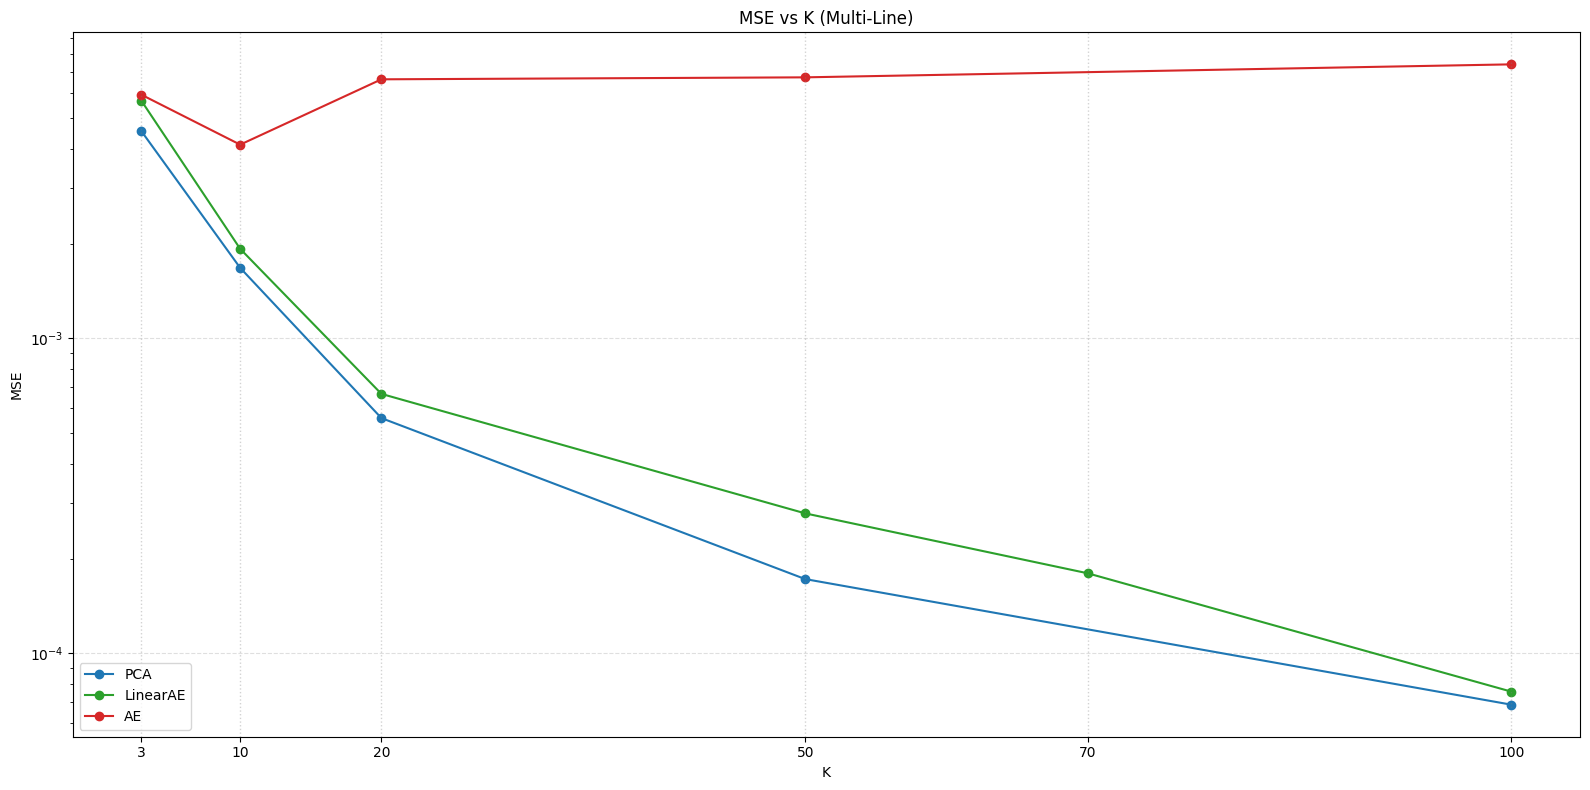

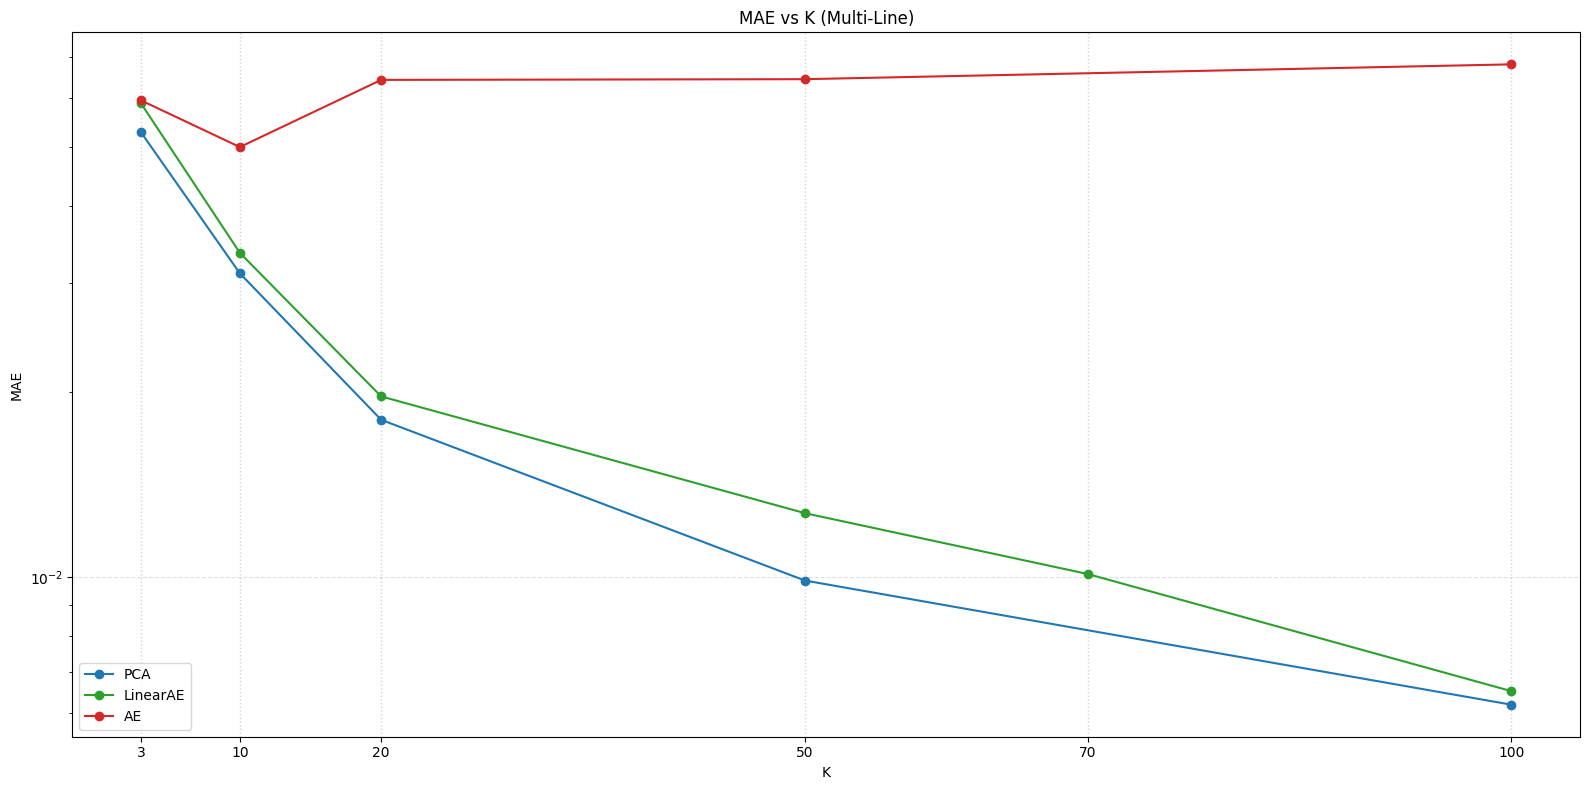

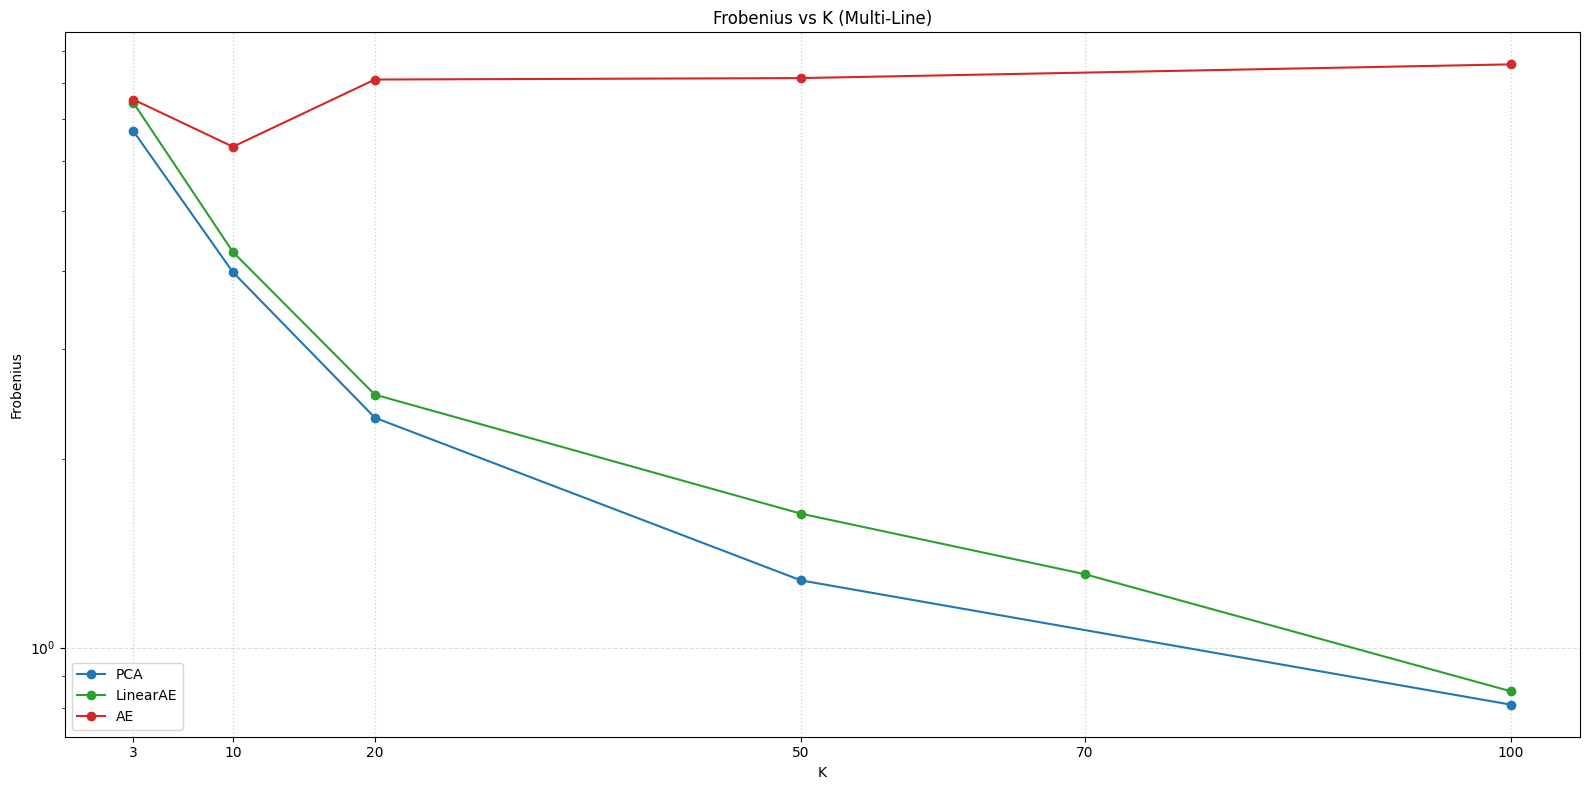

In [39]:
for metric in available_err_metrics:
    fig, ax = plt.subplots(figsize=(16, 8))
    all_x = []
    all_y = []
    for method in methods:
        subset = err_long[
            (err_long["metric"] == metric) & (err_long["method"] == method)
        ].sort_values("K")
        x_vals = subset["K"].to_numpy()
        y_vals = subset["error"].to_numpy()
        all_x.extend(x_vals.tolist())
        all_y.extend(y_vals.tolist())
        ax.plot(
            x_vals,
            y_vals,
            marker="o",
            label=method_labels.get(method, method),
            color=method_colors.get(method),
        )

    ax.set_title(f"{metric} vs K (Multi-Line)")
    ax.set_xlabel("K")
    ax.set_ylabel(metric)
    ax.set_yscale("log")
    if all_x:
        k_ticks = sorted(set(all_x))
        ax.set_xticks(k_ticks)
        for k_tick in k_ticks:
            ax.axvline(
                k_tick,
                linestyle=":",
                color="gray",
                alpha=0.35,
                linewidth=1,
            )
    ax.grid(axis="y", linestyle="--", alpha=0.4)
    ax.legend()
    plt.tight_layout()
    plot_path = comparison_dir / f"err_{metric}_vs_k.png"
    fig.savefig(plot_path, dpi=200, bbox_inches="tight")
    plt.show()

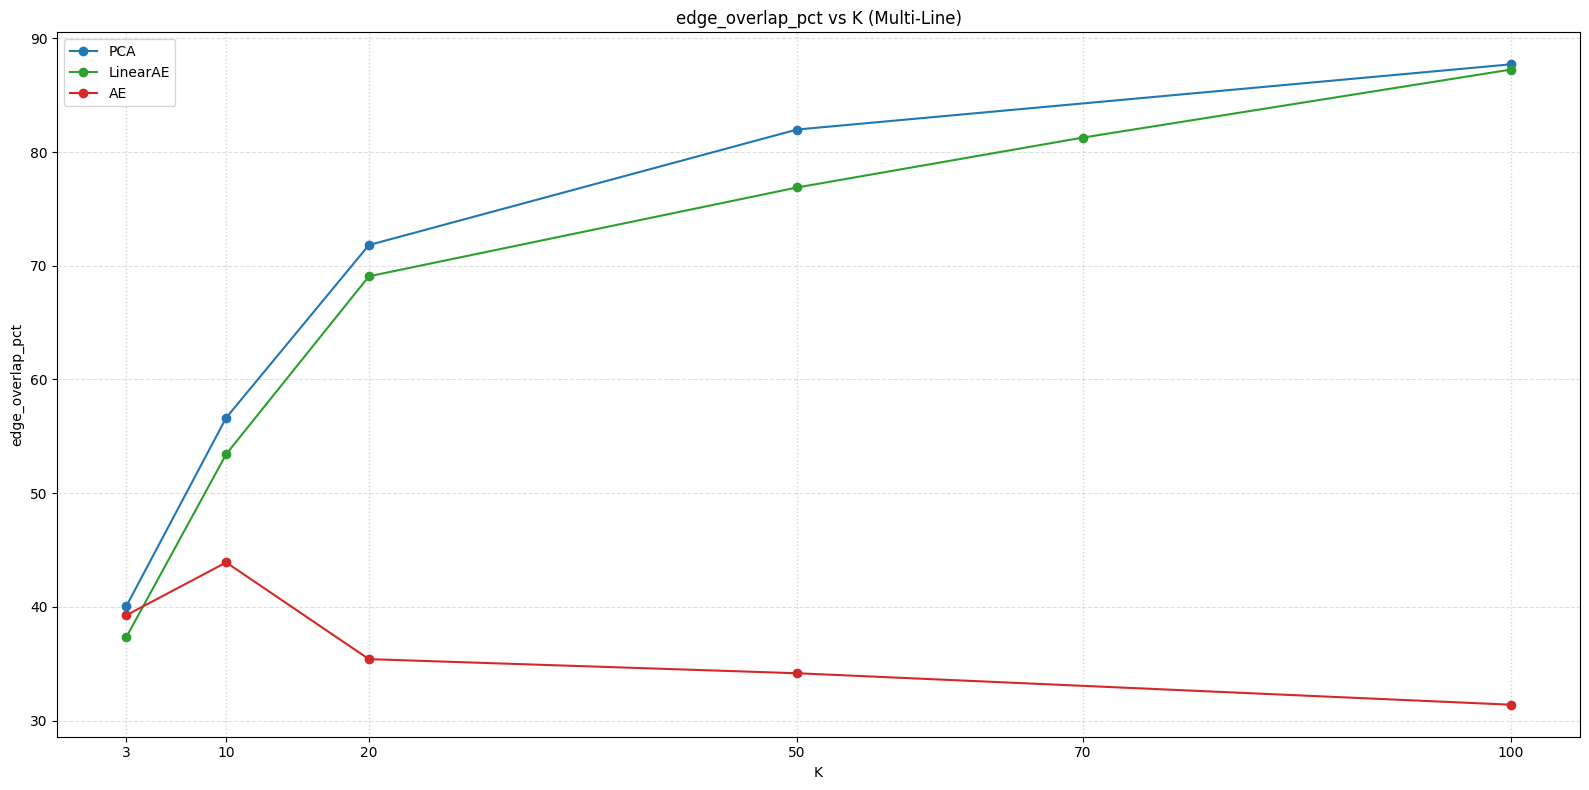

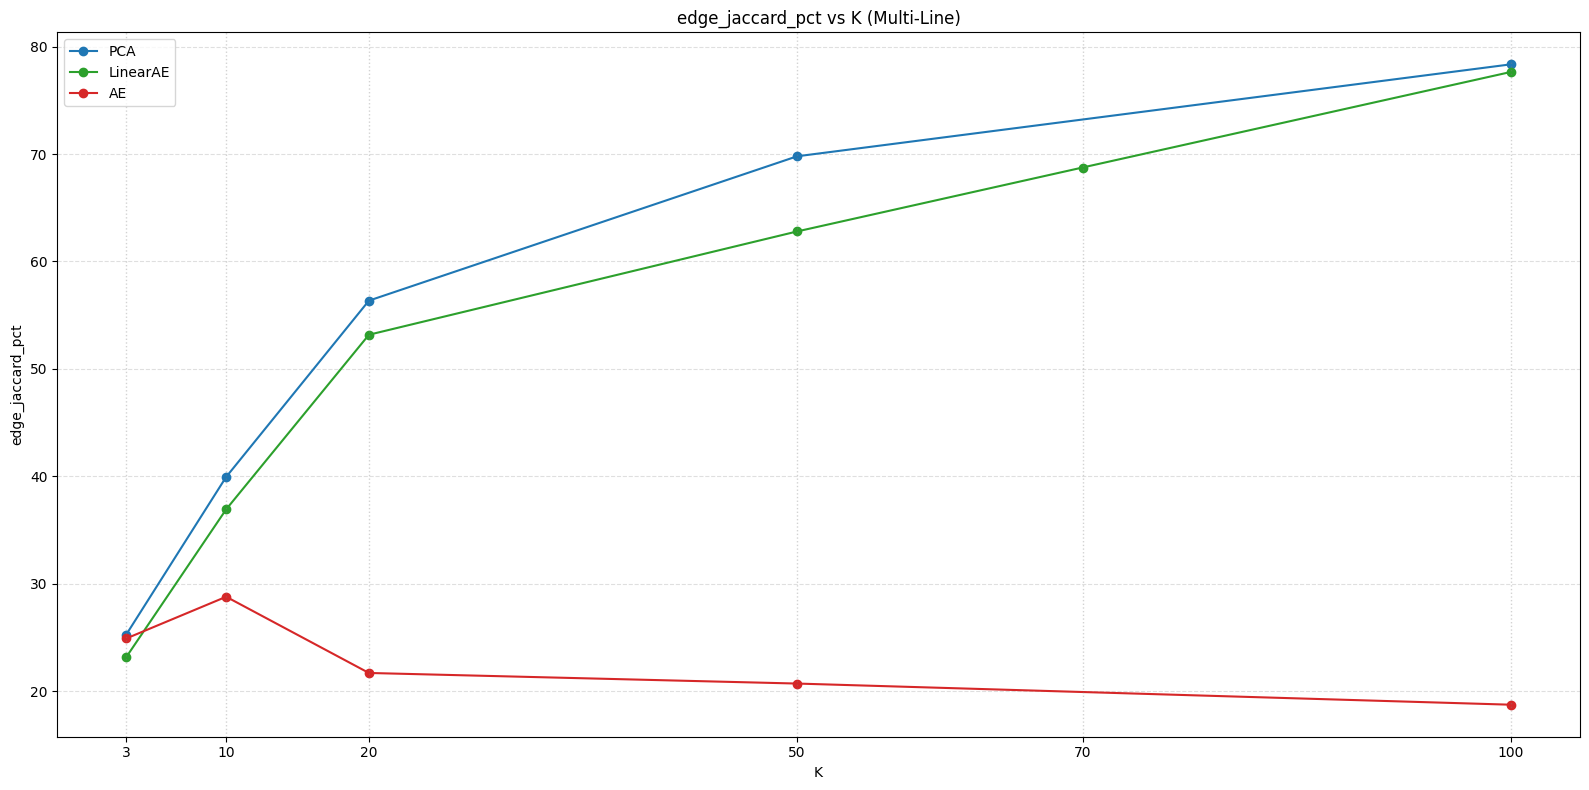

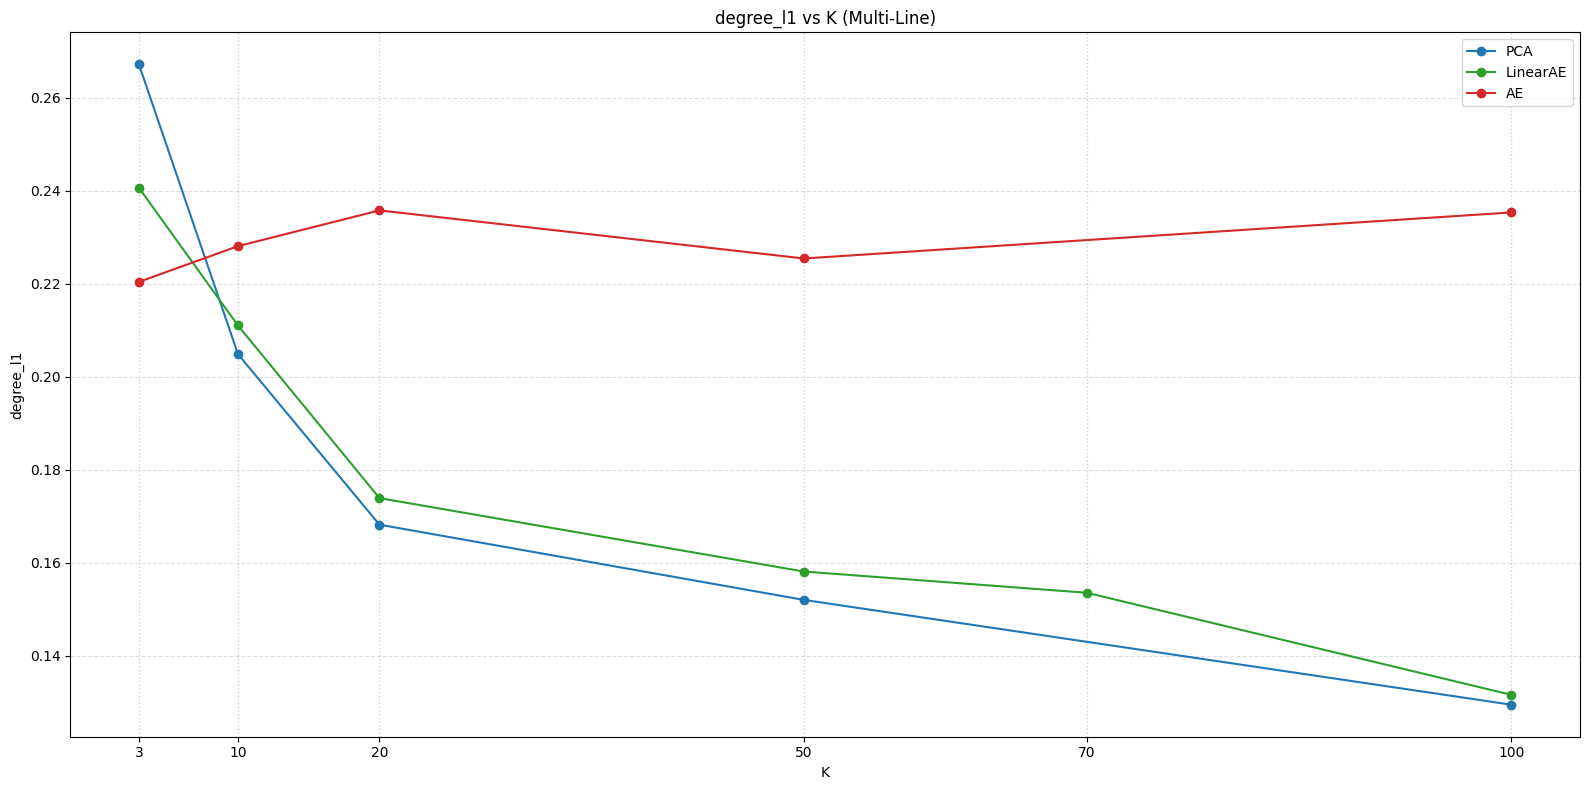

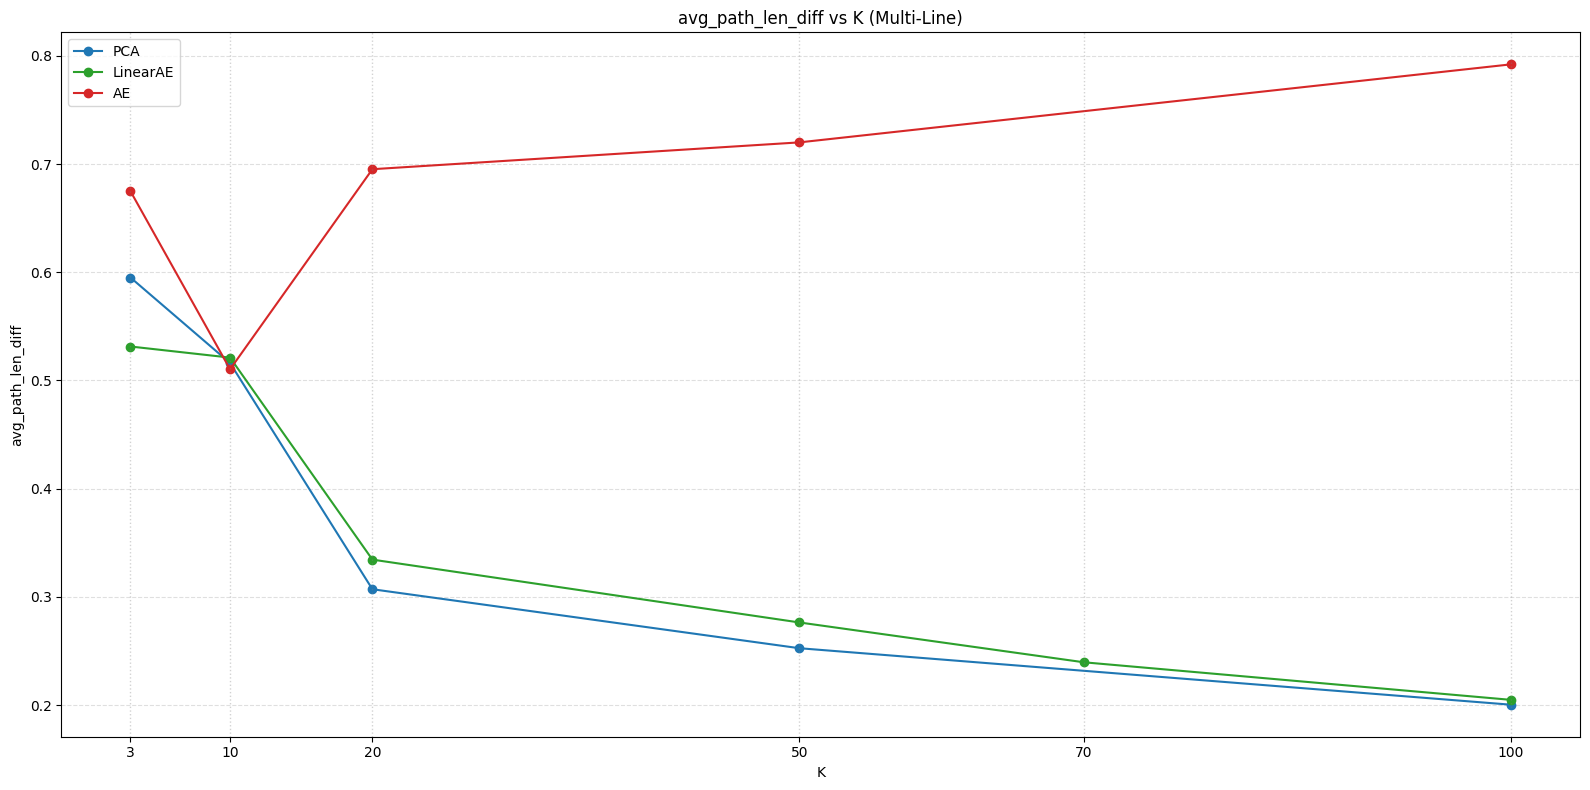

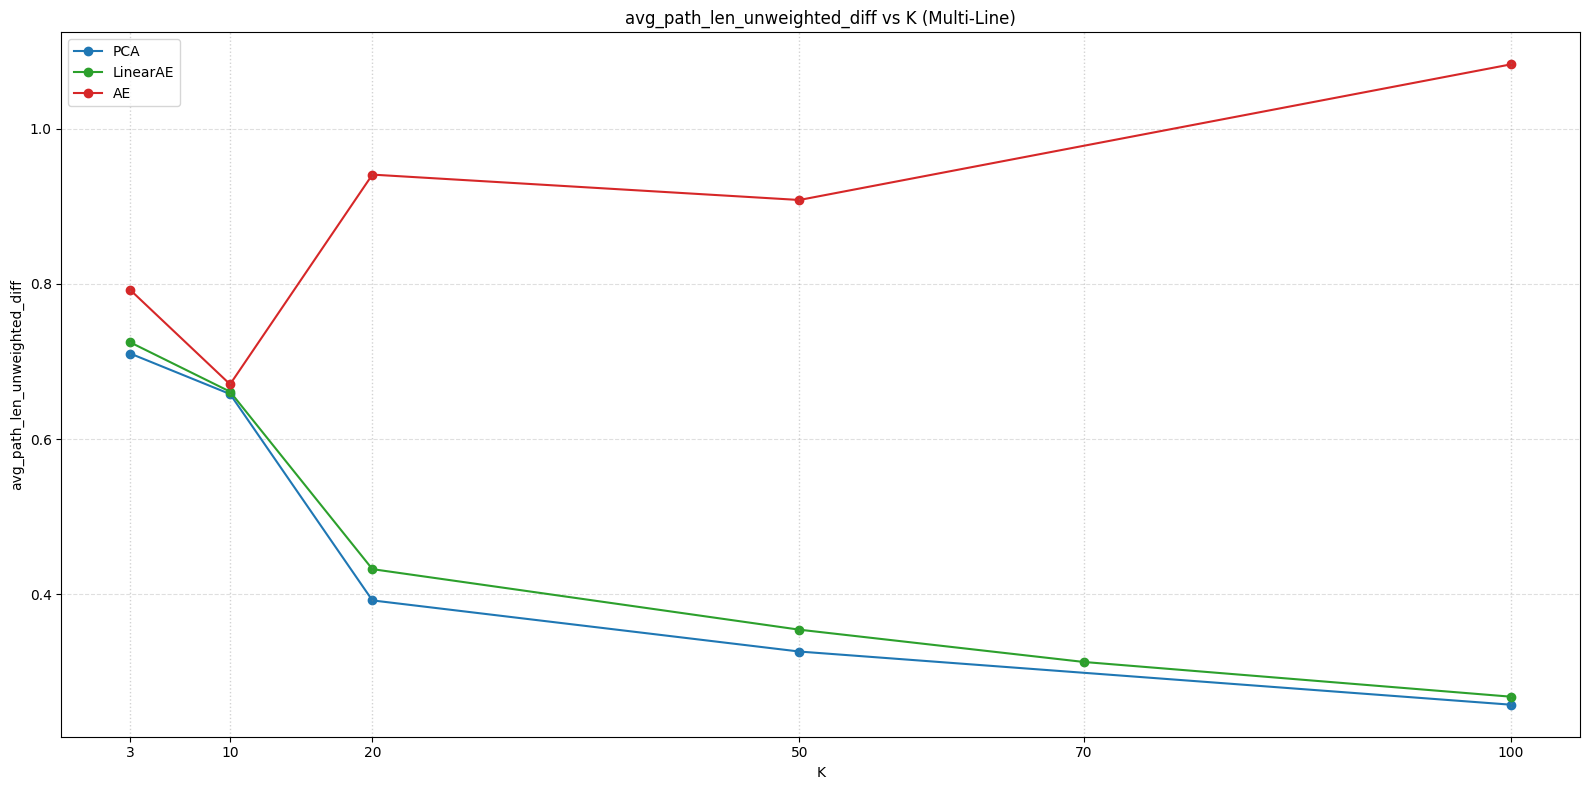

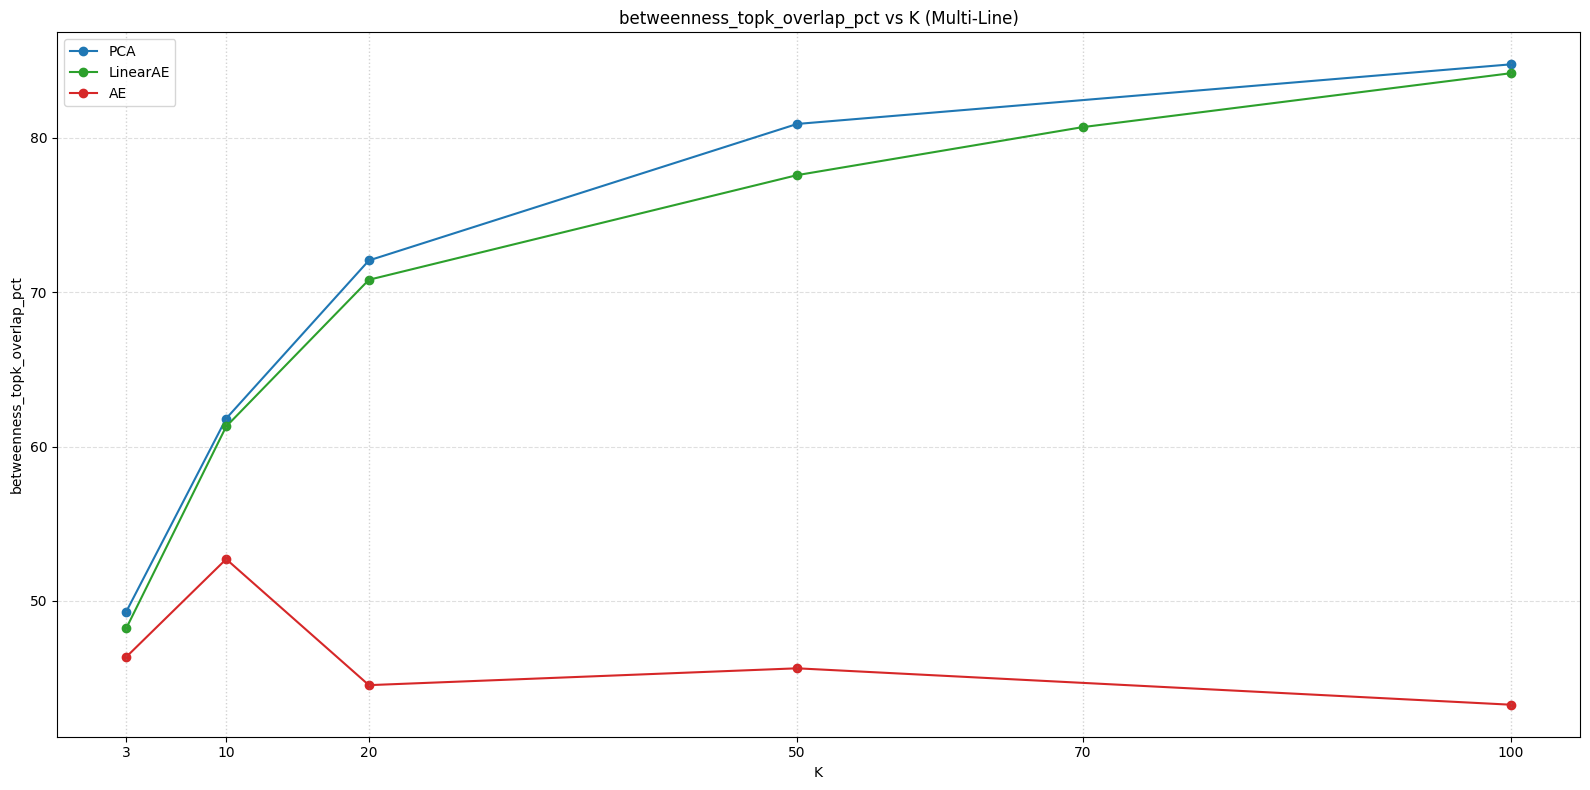

In [40]:
# MST K-based comparison plots
mst_by_model = mst_means.join(meta_df)
mst_by_model = mst_by_model.dropna(subset=["K", "method"]).copy()
mst_by_model["K"] = mst_by_model["K"].astype(int)

if mst_by_model.empty:
    raise ValueError("No valid MST models with parsed K were found.")

mst_long = mst_by_model.melt(
    id_vars=["method", "K"],
    value_vars=available_mst_metrics,
    var_name="metric",
    value_name="value",
)

mst_methods = [m for m in method_order if m in mst_long["method"].unique()]
if not mst_methods:
    mst_methods = sorted(mst_long["method"].unique())

mst_ks_sorted = sorted(mst_long["K"].unique())

for metric in available_mst_metrics:
    fig, ax = plt.subplots(figsize=(16, 8))
    all_x = []
    all_y = []
    for method in mst_methods:
        subset = mst_long[
            (mst_long["metric"] == metric) & (mst_long["method"] == method)
        ].sort_values("K")
        if subset.empty:
            continue
        x_vals = subset["K"].to_numpy()
        y_vals = subset["value"].to_numpy()
        all_x.extend(x_vals.tolist())
        all_y.extend(y_vals.tolist())
        ax.plot(
            x_vals,
            y_vals,
            marker="o",
            label=method_labels.get(method, method),
            color=method_colors.get(method),
        )

    ax.set_title(f"{metric} vs K (Multi-Line)")
    ax.set_xlabel("K")
    ax.set_ylabel(metric)
    if all_x:
        k_ticks = sorted(set(all_x))
        ax.set_xticks(k_ticks)
        for k_tick in k_ticks:
            ax.axvline(
                k_tick,
                linestyle=":",
                color="gray",
                alpha=0.35,
                linewidth=1,
            )
    if all_y:
        y_min = min(all_y)
        y_max = max(all_y)
        if y_min > 0 and (y_max / y_min) >= 1000:
            ax.set_yscale("log")
    ax.grid(axis="y", linestyle="--", alpha=0.4)
    ax.legend()
    plt.tight_layout()
    plot_path = comparison_dir / f"mst_{metric}_vs_k.png"
    fig.savefig(plot_path, dpi=200, bbox_inches="tight")
    plt.show()